# K-Means Clustering

**Topic:** Unsupervised Learning — Clustering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from tkh_utils import PALETTE


---
## What you'll explore

By the end of this demo you will be able to:

- **Describe** how k-means assigns points to clusters using distance to centroids
- **Explain** why k-means requires K in advance and how initialization affects results
- **Interpret** an inertia curve to choose a reasonable number of clusters

> **Tip:** The diagram below marks each centroid with a large ✕ sitting at the center of its cluster. For an animated, step-by-step view of centroids drifting into place, try the linked interactive visualizer.

---
## How we got here

In **[math/linear_algebra/06_norms_and_distances.ipynb](../math/linear_algebra/06_norms_and_distances.ipynb)** you learned how Euclidean distance is computed. In **[ml_concepts/11_the_curse_of_dimensionality.ipynb](../ml_concepts/11_the_curse_of_dimensionality.ipynb)** you learned why distance-based methods degrade in high dimensions. In **[preprocessing/03_scaling_and_normalization.ipynb](../preprocessing/03_scaling_and_normalization.ipynb)** you learned that unscaled features distort distance calculations.

All three foundations are active inside k-means every time it assigns a point to a centroid.

---
## Why this matters for data science

K-means is the "hello world" of unsupervised learning: fast, interpretable, and surprisingly effective for customer segmentation, document clustering, image color quantization, and market basket grouping. Understanding it deeply prepares you for every more complex clustering algorithm that follows.

\
---
## Where it sits on the spectrum

Referencing **[ml_concepts/13_interpretability_vs_complexity.ipynb](../ml_concepts/13_interpretability_vs_complexity.ipynb)**:

**Interpretability: High.** Each cluster is summarized by a centroid with the same units as your original features. You can describe "Cluster 2" as "average age 28, income $45k, spending score 72."

**Complexity: Low.** Time complexity O(n × K × d × i): linear in samples, clusters, dimensions, and iterations. Scales to millions of rows.

**Position:** High-interpretability, low-complexity corner — the most practical corner for business applications where clusters must be explained to non-technical stakeholders.

---
## How it learns

**Step 1 — Initialize.** Choose K points (using k-means++ by default: spread-out initialization) as initial centroids.

**Step 2 — Assign.** For every data point, compute its Euclidean distance to each centroid. Assign the point to the nearest centroid's cluster.

**Step 3 — Update.** Move each centroid to the mean (average position) of all points currently assigned to it.

**Step 4 — Repeat.** Return to step 2 with the new centroid positions. Continue until no point changes cluster — that is convergence.

K-means is guaranteed to converge but not to find the global optimum. Running it multiple times (controlled by `n_init`) and keeping the lowest-inertia result is standard practice.

\
---
## The math behind it

K-means minimizes **within-cluster sum of squares (WCSS)**, also called inertia:

$$J = \sum_{i=1}^{K} \sum_{\mathbf{x} \in C_i} \|\mathbf{x} - \boldsymbol{\mu}_i\|^2$$

Where:
- $K$ = number of clusters you choose before training
- $C_i$ = the set of all points assigned to cluster $i$
- $\boldsymbol{\mu}_i$ = the centroid (mean vector) of cluster $i$
- $\|\mathbf{x} - \boldsymbol{\mu}_i\|$ = Euclidean distance from point $\mathbf{x}$ to its centroid

**Assignment step** — send each point to its nearest centroid:
$$C_i = \{\mathbf{x} : \|\mathbf{x} - \boldsymbol{\mu}_i\|^2 \leq \|\mathbf{x} - \boldsymbol{\mu}_j\|^2 \text{ for all } j \neq i\}$$

**Update step** — move centroid to the mean of its cluster:
$$\boldsymbol{\mu}_i = \frac{1}{|C_i|} \sum_{\mathbf{x} \in C_i} \mathbf{x}$$

Each iteration reduces $J$ or keeps it the same. Convergence occurs when $J$ stops decreasing.

---
## See it in action

The chart below shows what k-means does to a set of points: it starts with no labels at all, then sorts every point into one of K groups built around a centroid (marked with an ✕). For a fully interactive version — drag points, change K, and watch it converge step by step — try the [Clustering Visualizer](https://clustering-visualizer.web.app/kmeans).

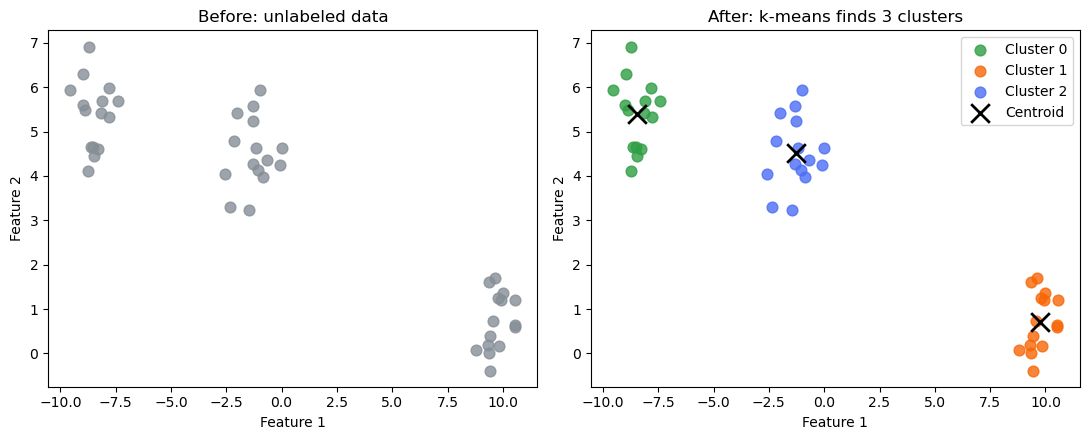

In [2]:
np.random.seed(7)
X_demo, true_demo = make_blobs(n_samples=45, centers=3, cluster_std=0.65, random_state=7)
km_demo = KMeans(n_clusters=3, n_init=10, random_state=7).fit(X_demo)
demo_colors = [PALETTE['accent'], PALETTE['secondary'], PALETTE['primary']]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(X_demo[:, 0], X_demo[:, 1], color=PALETTE['muted'], s=60, alpha=0.8)
axes[0].set_title('Before: unlabeled data')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

for k in range(3):
    mask = km_demo.labels_ == k
    axes[1].scatter(X_demo[mask, 0], X_demo[mask, 1], color=demo_colors[k],
                     s=60, alpha=0.8, label=f'Cluster {k}')
axes[1].scatter(km_demo.cluster_centers_[:, 0], km_demo.cluster_centers_[:, 1],
                 color='black', marker='x', s=180, linewidths=2, label='Centroid')
axes[1].set_title('After: k-means finds 3 clusters')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()

plt.tight_layout()
plt.show()


---
## What's happening?

The diagram above shows one clustering result: points sorted into groups, each with a centroid (✕) at its center. Getting there takes repeated assign-then-update steps. The code below runs that process on the same kind of data and reports how many iterations it took and the resulting inertia (WCSS). For a step-by-step animated view of centroids drifting into place, try the interactive visualizer linked above.

Choosing K is a separate decision from running the algorithm. Inertia decreases with every additional cluster: at K=n (one cluster per point), inertia reaches zero. The useful range is where adding one more cluster stops producing large inertia gains — that kink is the elbow. Notebook 06 covers three rigorous methods for finding the right K.

In [3]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)
X_sc = StandardScaler().fit_transform(X)

model = KMeans(
    n_clusters=4,
    n_init=10,
    init='k-means++',
    random_state=42,
)
model.fit(X_sc)

print(f'Inertia (WCSS): {model.inertia_:.2f}')
print(f'Cluster sizes:  {np.bincount(model.labels_)}')
print(f'Converged in:   {model.n_iter_} iterations')

Inertia (WCSS): 6.42
Cluster sizes:  [75 75 75 75]
Converged in:   2 iterations


---
## Real-world example: Discovering Customer Segments

K-means (K=4) applied to standardized make_blobs data — a proxy for two-feature customer data (e.g., annual spend and visit frequency). Centroids are the large X markers.

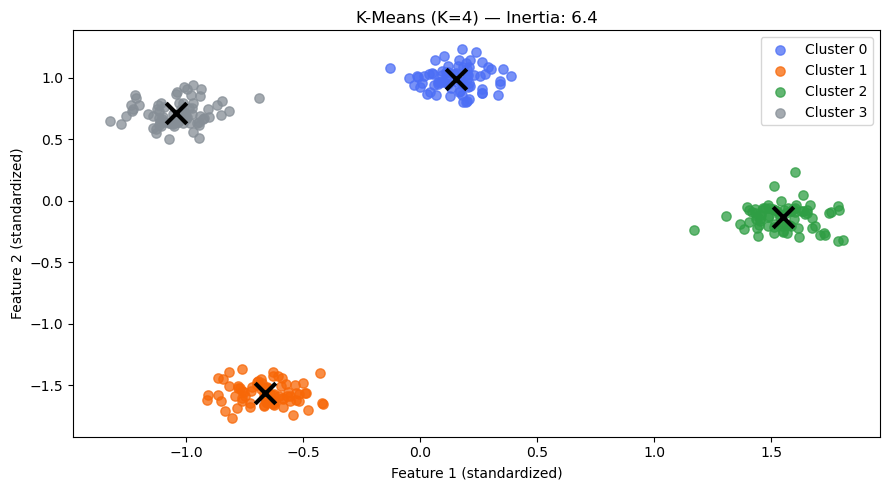

In [4]:
np.random.seed(42)
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)
X_sc = StandardScaler().fit_transform(X)
km = KMeans(n_clusters=4, n_init=10, random_state=42)
km.fit(X_sc)
labels  = km.labels_
centers = km.cluster_centers_

cluster_colors = [PALETTE['primary'], PALETTE['secondary'], PALETTE['accent'], PALETTE['muted']]
fig, ax = plt.subplots(figsize=(9, 5))
for k in range(4):
    mask = labels == k
    ax.scatter(X_sc[mask, 0], X_sc[mask, 1], color=cluster_colors[k], s=45, alpha=0.75, label=f'Cluster {k}')
ax.scatter(centers[:, 0], centers[:, 1], color='black', marker='x', s=220, linewidths=3)
ax.set_title(f'K-Means (K=4) — Inertia: {km.inertia_:.1f}')
ax.set_xlabel('Feature 1 (standardized)')
ax.set_ylabel('Feature 2 (standardized)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Key hyperparameters

**`n_clusters`** (required): The K. The most critical choice — k-means cannot discover it on its own. Use elbow + gap statistic + silhouette (notebook 06).

**`n_init`** (default 10): Times to run with different random centroids. Higher values reduce bad local minima. Keep at 10 or increase to 20 for important models.

**`init`** (default `'k-means++'`): Smart initialization — selects centroids that are spread out. Significantly better than fully random initialization.

sklearn docs: [sklearn.cluster.KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

---
## Strengths and weaknesses

| Strength | Weakness |
|----------|----------|
| Fast and scalable — O(n × K × d × i) | Requires K to be specified in advance |
| Highly interpretable (centroid = cluster summary) | Assumes spherical, equal-sized clusters |
| Works well on well-separated, compact clusters | Sensitive to outliers (pulls centroids) |
| Scales to millions of samples | Fails on non-convex cluster shapes |
| Deterministic given K, init, and seed | Sensitive to feature scale — scale first |

---
## When to use it / When NOT to use it

| Use k-means when... | Do NOT use k-means when... |
|---------------------|---------------------------|
| You have a rough idea of K | You have no idea how many clusters exist |
| Clusters are roughly spherical and equal-sized | Clusters have very different sizes or densities |
| Dataset is large (>10,000 samples) | Data has many outliers that would pull centroids |
| Features are numeric and scaled | Cluster shapes are non-convex (crescents, rings) |
| You need fast, interpretable results | You need soft (probabilistic) cluster assignments |

---
## Key takeaway

> **K-means is fast, interpretable, and effective for spherical clusters — but always scale your features first, run it multiple times with different seeds, and use three evaluation metrics to choose K.**

---
*Next up: 03_gaussian_mixture_models — where clusters get soft boundaries and the algorithm models the full probability distribution of each group*